# Visualisation des Datas et Résultats du réseau de diffusion.


---
## Configuration

Cette section regroupe les imports, les chemins et les petites fonctions utilitaires utilisees dans le reste du notebook.

In [222]:
import os
import sys
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.nn.functional import adaptive_avg_pool2d
from torch.utils.data import DataLoader, TensorDataset

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

pytorch_fid_src = project_root / "lib" / "pytorch-fid-master" / "src"
if str(pytorch_fid_src) not in sys.path:
    sys.path.insert(0, str(pytorch_fid_src))

from lib.PhyFID.metrics import compare_datasets
from lib.PhyFID.utils import evaluate_phyfid_dataset
from pytorch_fid.fid_score import calculate_frechet_distance as pytorch_fid_distance
from pytorch_fid.inception import InceptionV3


In [223]:
DATA_ROOT = "../data/RT28"
PROCESSED_ROOT = os.path.join(DATA_ROOT, "processed")

TRAIN_PT = os.path.join(PROCESSED_ROOT, "training.pt")
TEST_PT = os.path.join(PROCESSED_ROOT, "test.pt")
VAL_PT = os.path.join(PROCESSED_ROOT, "validation.pt")

BIG_TRAIN_PT = os.path.join(PROCESSED_ROOT, "training-b.pt")
BIG_VAL_PT = os.path.join(PROCESSED_ROOT, "validation-b.pt")

GENERATED_PT = "generated/generated_dataset.pt"
NOISE_PT = "generated/noise_dataset.pt"
MNIST_PT = "../data/MNIST/processed/training.pt"

LOSS_CSV = "res/RT28-n1000.csv"

PHYFID_ENCODER = "out/phyfid_encoder.pt"
PHYFID_STATS = "out/phyfid_val_stats.npz"
PHYFID_BATCH_SIZE = 128

FID_DIMS = 64
FID_BATCH_SIZE = 25
FID_DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [224]:
def load_pt_dataset(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"Fichier introuvable: {path}")
    return torch.load(path, map_location="cpu", weights_only=True)


def show_grid(images, n=16, cols=4, cmap="gray", seed=0, save=False, save_path="grid.png", title=None, colorbar=False):
    rng = np.random.default_rng(seed)
    total = images.shape[0]
    n = min(n, total)
    rows = int(np.ceil(n / cols))
    indices = rng.choice(total, size=n, replace=False)

    if colorbar:
        fig = plt.figure(figsize=(cols * 2.2 + 0.45, rows * 2.2), constrained_layout=True)
        gs = fig.add_gridspec(rows, cols + 1, width_ratios=[1] * cols + [0.06], wspace=0.02)
        axes = np.array([[fig.add_subplot(gs[r, c]) for c in range(cols)] for r in range(rows)])
        cax = fig.add_subplot(gs[:, -1])
    else:
        fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.2, rows * 2.2), squeeze=False, constrained_layout=True)
        cax = None

    im_ref = None
    for i, idx in enumerate(indices):
        r, c = divmod(i, cols)
        ax = axes[r, c]
        img = images[idx].detach().cpu().numpy() if torch.is_tensor(images) else images[idx]
        if img.ndim == 3 and img.shape[0] == 1:
            img = img[0]
        im_ref = ax.imshow(img, cmap=cmap)
        ax.set_title(f"idx={idx}")
        ax.axis("off")

    for j in range(n, rows * cols):
        r, c = divmod(j, cols)
        axes[r, c].axis("off")

    if title:
        fig.suptitle(title, fontsize=16)
    if colorbar and im_ref is not None:
        fig.colorbar(im_ref, cax=cax)
    if save:
        fig.savefig(save_path, bbox_inches="tight")
    plt.show()


def print_dataset_summary(name, images):
    tensor = torch.as_tensor(images).float()
    print(
        f"{name:<12} shape={tuple(images.shape)!s:<18} dtype={images.dtype} "
        f"min={tensor.min().item():8.3f} max={tensor.max().item():8.3f} "
        f"mean={tensor.mean().item():8.3f} std={tensor.std().item():8.3f}"
    )


def normalize_generated_dataset(images, value_min=0, value_max=255):
    """Remet les sorties DDPM dans la convention uint8-like [0, 255] du dataset RT.

    La normalisation est faite image par image sur les deux dimensions spatiales,
    comme lors du preprocessing des champs RT.
    """
    data = images.float() if torch.is_tensor(images) else torch.as_tensor(images).float()
    reduce_dims = tuple(range(data.ndim)) if data.ndim <= 2 else (-2, -1)
    min_value = data.amin(dim=reduce_dims, keepdim=True)
    max_value = data.amax(dim=reduce_dims, keepdim=True)
    scale = max_value - min_value
    safe_scale = torch.where(scale == 0, torch.ones_like(scale), scale)
    normalized = (data - min_value) / safe_scale
    normalized = normalized * (value_max - value_min) + value_min
    return torch.where(scale == 0, torch.zeros_like(data), normalized)


---
## Verification du Dataset

On verifie les dimensions, les types et quelques exemples visuels. Les sorties DDPM sauvegardees sont normalisees image par image dans la meme convention que les donnees RT pretraitees.

In [225]:
train_images = load_pt_dataset(TRAIN_PT)
test_images = load_pt_dataset(TEST_PT)
val_images = load_pt_dataset(VAL_PT)
big_train = load_pt_dataset(BIG_TRAIN_PT)
big_val = load_pt_dataset(BIG_VAL_PT)

generated_raw = load_pt_dataset(GENERATED_PT)
noise_raw = load_pt_dataset(NOISE_PT)
generated_dataset = normalize_generated_dataset(generated_raw)
noise_dataset = normalize_generated_dataset(noise_raw)
mnist_dataset = load_pt_dataset(MNIST_PT)

for name, dataset in {
    "train": train_images,
    "validation": val_images,
    "test": test_images,
    "big_train": big_train,
    "big_val": big_val,
    "generated": generated_dataset,
    "noise": noise_dataset,
    "MNIST": mnist_dataset,
}.items():
    print_dataset_summary(name, dataset)


train        shape=(2611, 28, 28)     dtype=torch.uint8 min=   0.000 max= 255.000 mean= 126.509 std= 121.117
validation   shape=(326, 28, 28)      dtype=torch.uint8 min=   0.000 max= 255.000 mean= 126.535 std= 120.657
test         shape=(327, 28, 28)      dtype=torch.uint8 min=   0.000 max= 255.000 mean= 126.496 std= 121.105
big_train    shape=(52224, 28, 28)    dtype=torch.uint8 min=   0.000 max= 255.000 mean= 126.510 std= 121.073
big_val      shape=(6528, 28, 28)     dtype=torch.uint8 min=   0.000 max= 255.000 mean= 126.513 std= 121.057
generated    shape=(1000, 1, 28, 28)  dtype=torch.float32 min=   0.000 max= 255.000 mean= 127.082 std= 118.975
noise        shape=(1000, 1, 28, 28)  dtype=torch.float32 min=   0.000 max= 255.000 mean= 127.367 std=  41.649
MNIST        shape=(54000, 28, 28)    dtype=torch.uint8 min=   0.000 max= 255.000 mean=  33.321 std=  78.572


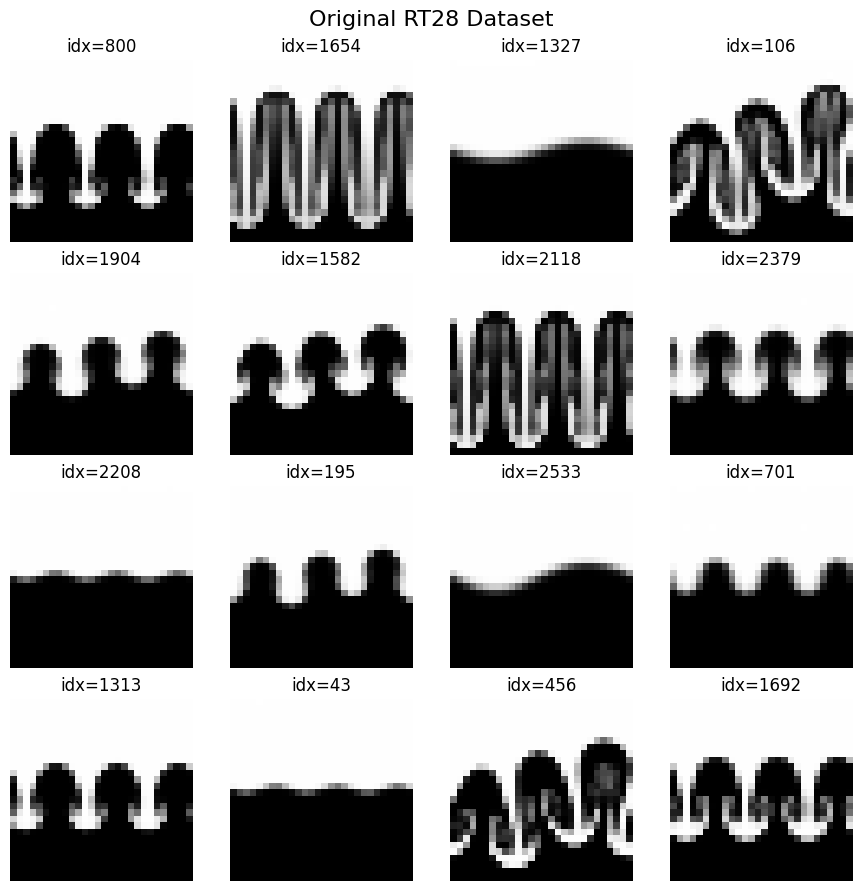

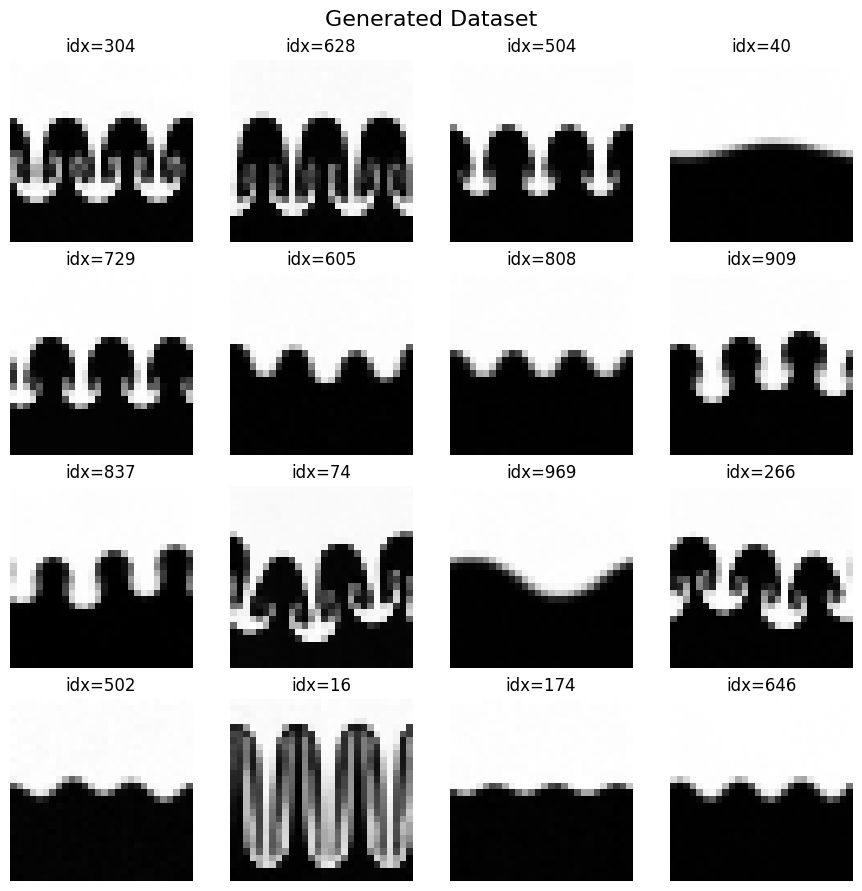

In [226]:
show_grid(train_images, n=16, cols=4, save=True, save_path="original.png", title="Original RT28 Dataset", colorbar=False)
show_grid(generated_dataset, n=16, cols=4, save=True, save_path="generated.png", title="Generated Dataset", colorbar=False)


---
## Information sur l'entrainement


In [227]:
def plot_loss_curve(csv_path):
    data = np.genfromtxt(csv_path, delimiter=",", names=True, dtype=None, encoding="utf-8")
    if "epoch" not in data.dtype.names or "train_loss" not in data.dtype.names:
        raise ValueError("Le CSV doit contenir les colonnes 'epoch' et 'train_loss'.")

    epochs = data["epoch"]
    train_loss = data["train_loss"]
    val_loss = data["val_loss"] if "val_loss" in data.dtype.names else None
    best_loss = data["best_loss"] if "best_loss" in data.dtype.names else None

    fig, ax = plt.subplots(1, 2, figsize=(10, 3))
    ax[0].plot(epochs, train_loss, label="train_loss")
    if val_loss is not None:
        ax[0].plot(epochs, val_loss, label="val_loss", alpha=0.8)
    if best_loss is not None:
        ax[0].plot(epochs, best_loss, label="best_loss", alpha=0.8)
    ax[0].set_xlabel("Epoch")
    ax[0].set_ylabel("Loss")
    ax[0].set_title("RT28 loss")
    ax[0].legend()

    eps = 1e-12
    ax[1].plot(epochs, np.log(np.clip(train_loss, eps, None)), label="log(train_loss)")
    if val_loss is not None:
        ax[1].plot(epochs, np.log(np.clip(val_loss, eps, None)), label="log(val_loss)", alpha=0.8)
    if best_loss is not None:
        ax[1].plot(epochs, np.log(np.clip(best_loss, eps, None)), label="log(best_loss)", alpha=0.8)
    ax[1].set_xlabel("Epoch")
    ax[1].set_ylabel("Log loss")
    ax[1].set_title("RT28 log loss")
    ax[1].legend()

    fig.tight_layout()
    plt.show()


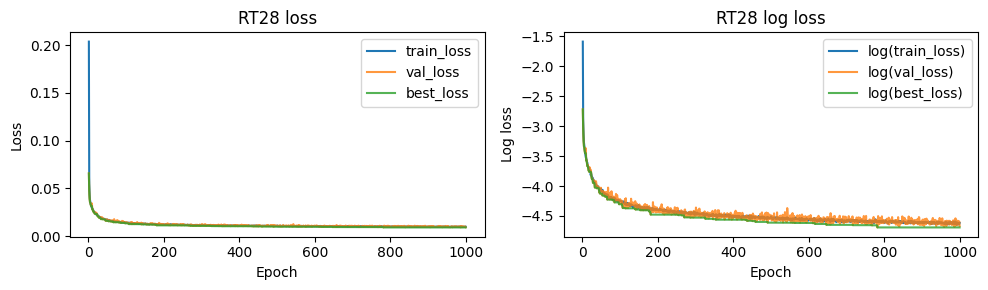

In [228]:
plot_loss_curve(LOSS_CSV)

---
# Metriques

Les métriques utilisé pour la comparaison des données génerées avec celles d'origines.

## FID

Le FID (*Frechet Inception Distance*) compare deux jeux d'images apres projection dans un espace de features. On note $\phi$ l'extracteur de features, par exemple InceptionV3 pour le FID classique, ou l'encodeur appris dans le cas du PhyFID. Pour un jeu de reference $X = \{x_i\}_{i=1}^{n}$ et un jeu genere $Y = \{y_i\}_{i=1}^{m}$, on travaille donc avec
$$ z_i^X = \phi(x_i) \in \mathbb{R}^d, \qquad z_i^Y = \phi(y_i) \in \mathbb{R}^d. $$

Comme pour l'ACP du notebook de comparaison, le dataset est resume dans un espace latent par sa moyenne et sa covariance. Pour le jeu de reference :
$$ \mu_X = \frac{1}{n}\sum_{i=1}^{n} z_i^X, \qquad
\Sigma_X = \frac{1}{n-1}\sum_{i=1}^{n}(z_i^X-\mu_X)(z_i^X-\mu_X)^T. $$
On definit de meme $\mu_Y$ et $\Sigma_Y$ pour les images generees.

L'hypothese du FID est que les features de chaque jeu peuvent etre approximees par une loi gaussienne multivariee,
$$ z^X \sim \mathcal{N}(\mu_X, \Sigma_X), \qquad z^Y \sim \mathcal{N}(\mu_Y, \Sigma_Y). $$
Le score est alors la distance de Frechet/Wasserstein-2 entre ces deux gaussiennes :
$$ \mathrm{FID}(X,Y) = \|\mu_X-\mu_Y\|_2^2 + \mathrm{Tr}\left(\Sigma_X + \Sigma_Y - 2(\Sigma_X\Sigma_Y)^{1/2}\right). $$

Intuitivement, le premier terme mesure l'ecart entre les centres des deux nuages de features, tandis que le terme de covariance mesure l'ecart entre leurs dispersions et correlations. Un score faible signifie donc que les deux jeux sont proches statistiquement dans l'espace choisi par $\phi$.

Dans ce notebook, deux choix de $\phi$ sont testes :
- **PhyFID** : $\phi$ est un encodeur entraine sur les simulations RT, donc l'espace de comparaison est adapte au dataset physique.
- **FID Inception** : $\phi$ est InceptionV3 pre-entraine sur des images naturelles, ce qui donne une baseline standard mais pas necessairement optimale pour des champs physiques 2D.

La normalisation est critique : $\phi$ ne compare pas seulement les formes visibles, mais les valeurs numeriques fournies au reseau. Les deux ensembles doivent donc etre convertis dans la meme convention avant l'extraction des features.

### PhyFID

PhyFID apprend un encodeur sur `TRAIN_PT`, sauvegarde cet encodeur, puis compare les datasets dans l'espace de features appris. Dans ce notebook, l'encodeur et les statistiques de reference sont simplement rechargees depuis `out/` pour eviter de relancer l'entrainement.

In [229]:
PHYFID_N_IMAGES = min(1000, len(big_val) // 2, len(big_train), len(generated_dataset), len(noise_dataset), len(mnist_dataset))
phyfid_reference = big_val[:PHYFID_N_IMAGES]

phyfid_datasets = {
    "val vs val": big_val[PHYFID_N_IMAGES:2 * PHYFID_N_IMAGES],
    "val vs train": big_train[:PHYFID_N_IMAGES],
    "val vs generated": generated_dataset[:PHYFID_N_IMAGES],
    "val vs noise": noise_dataset[:PHYFID_N_IMAGES],
    "val vs MNIST": mnist_dataset[:PHYFID_N_IMAGES],
}

phyfid_scores = {
    name: compare_datasets(phyfid_reference, dataset, PHYFID_ENCODER, batch_size=PHYFID_BATCH_SIZE)
    for name, dataset in phyfid_datasets.items()
}

print(f"Comparaison PhyFID sur {PHYFID_N_IMAGES} images")
for name, score in phyfid_scores.items():
    print(f"{name:<18} {score:>10.4f}")


Comparaison PhyFID sur 1000 images
val vs val             0.1165
val vs train           0.1125
val vs generated       0.1893
val vs noise          18.0439
val vs MNIST          15.2633


### FID Inception standard

Cette baseline utilise directement l'InceptionV3 pre-entraine du depot local `lib/pytorch-fid-master`. Les cartes RT en niveaux de gris sont repetees sur trois canaux. Comme les jeux generes ne contiennent ici que 1000 images, le bloc a 64 features est utilise pour limiter les problemes de covariance singuliere ; le FID standard a 2048 features demande plutot plusieurs milliers d'images. Ces scores servent surtout a comparer l'ordre relatif des jeux de donnees.

In [230]:
def prepare_images_for_fid(images):
    """Convertit NHW/NCHW/NHWC en RGB NCHW dans [0, 1]."""
    original_dtype = torch.as_tensor(images).dtype
    images = torch.as_tensor(images).detach().cpu().float()

    if images.ndim == 3:
        images = images.unsqueeze(1)
    elif images.ndim == 4 and images.shape[-1] in (1, 3) and images.shape[1] not in (1, 3):
        images = images.permute(0, 3, 1, 2)
    if images.ndim != 4:
        raise ValueError(f"Format non supporte: {tuple(images.shape)}")

    if original_dtype == torch.uint8 or (images.min() >= 0 and images.max() > 1):
        images = images / 255.0
    elif images.min() < 0:
        images = (images + 1.0) / 2.0

    images = images.clamp(0.0, 1.0)
    if images.shape[1] == 1:
        images = images.repeat(1, 3, 1, 1)
    if images.shape[1] != 3:
        raise ValueError(f"FID attend 1 ou 3 canaux, recu: {images.shape[1]}")
    return images


def extract_fid_features(images, model, batch_size, device):
    images = prepare_images_for_fid(images)
    loader = DataLoader(TensorDataset(images), batch_size=batch_size, shuffle=False)
    features = []

    model.eval()
    with torch.no_grad():
        for (batch,) in loader:
            prediction = model(batch.to(device))[0]
            if prediction.shape[-2:] != (1, 1):
                prediction = adaptive_avg_pool2d(prediction, output_size=(1, 1))
            features.append(prediction.flatten(1).cpu().numpy())

    return np.concatenate(features, axis=0)


def fid_from_features(reference_features, compared_features):
    reference_mu = np.mean(reference_features, axis=0)
    reference_sigma = np.cov(reference_features, rowvar=False)
    compared_mu = np.mean(compared_features, axis=0)
    compared_sigma = np.cov(compared_features, rowvar=False)
    return float(pytorch_fid_distance(reference_mu, reference_sigma, compared_mu, compared_sigma))


In [231]:
# FID_N_IMAGES = PHYFID_N_IMAGES
# fid_block = InceptionV3.BLOCK_INDEX_BY_DIM[FID_DIMS]
# fid_model = InceptionV3([fid_block]).to(FID_DEVICE)

# val_reference_features = extract_fid_features(big_val[:FID_N_IMAGES], fid_model, FID_BATCH_SIZE, FID_DEVICE)

# datasets_for_fid = {
#     "val vs val": big_val[FID_N_IMAGES:2 * FID_N_IMAGES],
#     "val vs train": big_train[:FID_N_IMAGES],
#     "val vs generated": generated_dataset[:FID_N_IMAGES],
#     "val vs noise": noise_dataset[:FID_N_IMAGES],
#     "val vs MNIST": mnist_dataset[:FID_N_IMAGES],
# }

# fid_scores = {}
# for name, dataset in datasets_for_fid.items():
#     compared_features = extract_fid_features(dataset, fid_model, FID_BATCH_SIZE, FID_DEVICE)
#     fid_scores[name] = fid_from_features(val_reference_features, compared_features)

# print(f"Comparaison sur {FID_N_IMAGES} images (Inception: {FID_DIMS} features)")
# print(f"{'Comparaison':<18} {'PhyFID':>12} {'FID Inception':>16}")
# for name in datasets_for_fid:
#     print(f"{name:<18} {phyfid_scores[name]:>12.4f} {fid_scores[name]:>16.4f}")

# del fid_model
# if torch.cuda.is_available():
#     torch.cuda.empty_cache()


---
## Metrique physique
Librairie de fonction utiles pour les métriques qui suivent

In [259]:
def to_txy(tensor):
    """Convertit (t, x, y) ou (t, 1, x, y) vers un tenseur float (t, x, y)."""
    tensor = torch.as_tensor(tensor).float()
    if tensor.ndim == 4 and tensor.shape[1] == 1:
        tensor = tensor[:, 0]
    if tensor.ndim != 3:
        raise ValueError(f"Tenseur attendu en (t, x, y) ou (t, 1, x, y), recu {tuple(tensor.shape)}")
    return tensor


def normalize_01(tensor, normalize=True):
    """Normalise en [0, 1] sans modifier le tenseur original."""
    tensor = to_txy(tensor)
    if normalize and tensor.max() > 1.5:
        tensor = tensor / 255.0
    return tensor


from scipy.stats import skewnorm


def fit_skewnorm_1d(values, min_scale=1e-6, max_abs_alpha=50):
    """Ajuste une loi skew-normal sur un vecteur 1D.

    Retourne les parametres scipy (alpha, loc, scale). Si les donnees sont
    presque constantes, on retombe sur une normale tres etroite.
    """
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if values.size == 0:
        return 0.0, 0.0, min_scale

    mean = float(np.mean(values))
    std = float(np.std(values))
    if values.size < 3 or std < min_scale:
        return 0.0, mean, max(std, min_scale)

    try:
        alpha, loc, scale = skewnorm.fit(values)
        if not np.isfinite([alpha, loc, scale]).all() or scale < min_scale:
            raise ValueError("Parametres skew-normal invalides")
        alpha = float(np.clip(alpha, -max_abs_alpha, max_abs_alpha))
        return alpha, float(loc), float(scale)
    except Exception:
        return 0.0, mean, max(std, min_scale)


def fit_skewnorm_layers(layer_values):
    """Ajuste une skew-normal pour chaque colonne x d'un tableau (t, x)."""
    layer_values = np.asarray(layer_values, dtype=float)
    params = np.array([fit_skewnorm_1d(layer_values[:, i]) for i in range(layer_values.shape[1])])
    return params[:, 0], params[:, 1], params[:, 2]


In [260]:
val_stats = normalize_01(val_images)
generated_stats = normalize_01(generated_dataset)
mnist_stats = normalize_01(mnist_dataset)
noise_stats = normalize_01(noise_dataset)

### Statitstiques par lignes
Definition des fonctions de calcules statistiques et de distances

In [261]:
def line_metric(validation, generated, metric_name="mu"):
    if validation.shape[1] != generated.shape[1]:
        raise ValueError(f"Le nombre de lignes (t) doit etre le meme pour validation et generated: {validation.shape[1]} vs {generated.shape[1]}")

    len = validation.shape[1]
    mu_val = validation.mean(dim=2).cpu().numpy()
    mu_gen = generated.mean(dim=2).cpu().numpy()
    if metric_name == "mu":
        MU_l_val = np.mean(mu_val, axis=0)
        MU_l_gen = np.mean(mu_gen, axis=0)
        distance = np.linalg.norm(MU_l_val - MU_l_gen) / len
        return distance, MU_l_gen, MU_l_val 
    elif metric_name == "sigma": # Ici on calcule la distance entre les écarts-types des moyennes par ligne
        SIGMA_l_val = np.std(mu_val, axis=0)
        SIGMA_l_gen = np.std(mu_gen, axis=0)
        distance = np.linalg.norm(SIGMA_l_val - SIGMA_l_gen) / len
        return distance, SIGMA_l_gen, SIGMA_l_val
    else:
        raise ValueError(f"Metric non supportee: {metric_name}")
    

def get_alpha(data):
    d = data.mean(dim=2).cpu().numpy()
    ALPHA_l_val, LOC_l_val, SCALE_l_val = fit_skewnorm_layers(d)
    return ALPHA_l_val, LOC_l_val, SCALE_l_val


Definition de fonctions d'affichages de joyplot pour comparer visuellement

In [262]:
def skewnorm_pdf(x, alpha, loc, scale):
    scale = float(scale)
    if scale <= 0:
        return np.zeros_like(x)
    return skewnorm.pdf(x, float(alpha), loc=float(loc), scale=scale)


def plot_skewnorm_joyplot(n_curves, alpha1, loc1, scale1, alpha2=None, loc2=None, scale2=None, *, ax=None, title="", label1="Validation", label2="Generated", color1="tab:blue", color2="tab:orange", x_min=-0.05, x_max=1.05):
    alpha1 = np.asarray(alpha1)
    loc1 = np.asarray(loc1)
    scale1 = np.asarray(scale1)
    if alpha1.shape != loc1.shape or loc1.shape != scale1.shape:
        raise ValueError("alpha1, loc1 et scale1 doivent avoir la meme forme")

    has_second = alpha2 is not None and loc2 is not None and scale2 is not None
    if has_second:
        alpha2 = np.asarray(alpha2)
        loc2 = np.asarray(loc2)
        scale2 = np.asarray(scale2)
        if alpha2.shape != loc2.shape or loc2.shape != scale2.shape or loc2.shape != loc1.shape:
            raise ValueError("alpha2/loc2/scale2 doivent avoir la meme forme que alpha1/loc1/scale1")

    if ax is None:
        _, ax = plt.subplots(figsize=(8, 3.5))

    n_curves = min(int(n_curves), len(loc1))
    selected_idx = np.linspace(0, len(loc1) - 1, n_curves, dtype=int)
    x = np.linspace(x_min, x_max, 800)
    spacing = 1.0
    height = 0.55

    for plot_idx, layer_idx in enumerate(selected_idx):
        offset = plot_idx * spacing

        y1 = skewnorm_pdf(x, alpha1[layer_idx], loc1[layer_idx], scale1[layer_idx])
        y1 = y1 / y1.max() * height if y1.max() > 0 else y1
        ax.fill_between(x, offset, offset + y1, color=color1, alpha=0.35)
        ax.plot(x, offset + y1, color=color1, linewidth=1.2, label=label1 if plot_idx == 0 else None)
        ax.axvline(loc1[layer_idx], ymin=offset / (n_curves * spacing), ymax=(offset + height) / (n_curves * spacing), color=color1, linestyle="--", linewidth=0.8, alpha=0.7)

        if has_second:
            y2 = skewnorm_pdf(x, alpha2[layer_idx], loc2[layer_idx], scale2[layer_idx])
            y2 = y2 / y2.max() * height if y2.max() > 0 else y2
            ax.fill_between(x, offset, offset + y2, color=color2, alpha=0.30)
            ax.plot(x, offset + y2, color=color2, linewidth=1.2, label=label2 if plot_idx == 0 else None)
            ax.axvline(loc2[layer_idx], ymin=offset / (n_curves * spacing), ymax=(offset + height) / (n_curves * spacing), color=color2, linestyle="--", linewidth=0.8, alpha=0.7)

    ax.set_xlim(x_min, x_max)
    ax.set_yticks(np.arange(n_curves) * spacing)
    ax.set_yticklabels([f"x={i}" for i in selected_idx])
    ax.set_xlabel(r"$\mu_l$")
    ax.set_ylabel("Ligne x")
    ax.set_title(title)
    ax.grid(axis="x", alpha=0.3)
    if has_second:
        ax.legend(loc="upper right")
    return ax

In [263]:
mu_l_dist_gen, mu_l_gen, mu_l_val = line_metric(val_stats, generated_stats, metric_name="mu")
mu_l_dist_noise, mu_l_noise, _ = line_metric(val_stats, noise_stats, metric_name="mu")
mu_l_dist_mnist, mu_l_mnist, _ = line_metric(val_stats, mnist_stats, metric_name="mu")

sigma_l_dist_gen, sigma_l_gen, sigma_l_val = line_metric(val_stats, generated_stats, metric_name="sigma")
sigma_l_dist_noise, sigma_l_noise, _ = line_metric(val_stats, noise_stats, metric_name="sigma")
sigma_l_dist_mnist, sigma_l_mnist, _ = line_metric(val_stats, mnist_stats, metric_name="sigma")

alpha_l_val, loc_l_val, scale_l_val = get_alpha(val_stats)
alpha_l_generated, loc_l_generated, scale_l_generated = get_alpha(generated_stats)
alpha_l_mnist, loc_l_mnist, scale_l_mnist = get_alpha(mnist_stats)
alpha_l_noise, loc_l_noise, scale_l_noise = get_alpha(noise_stats)

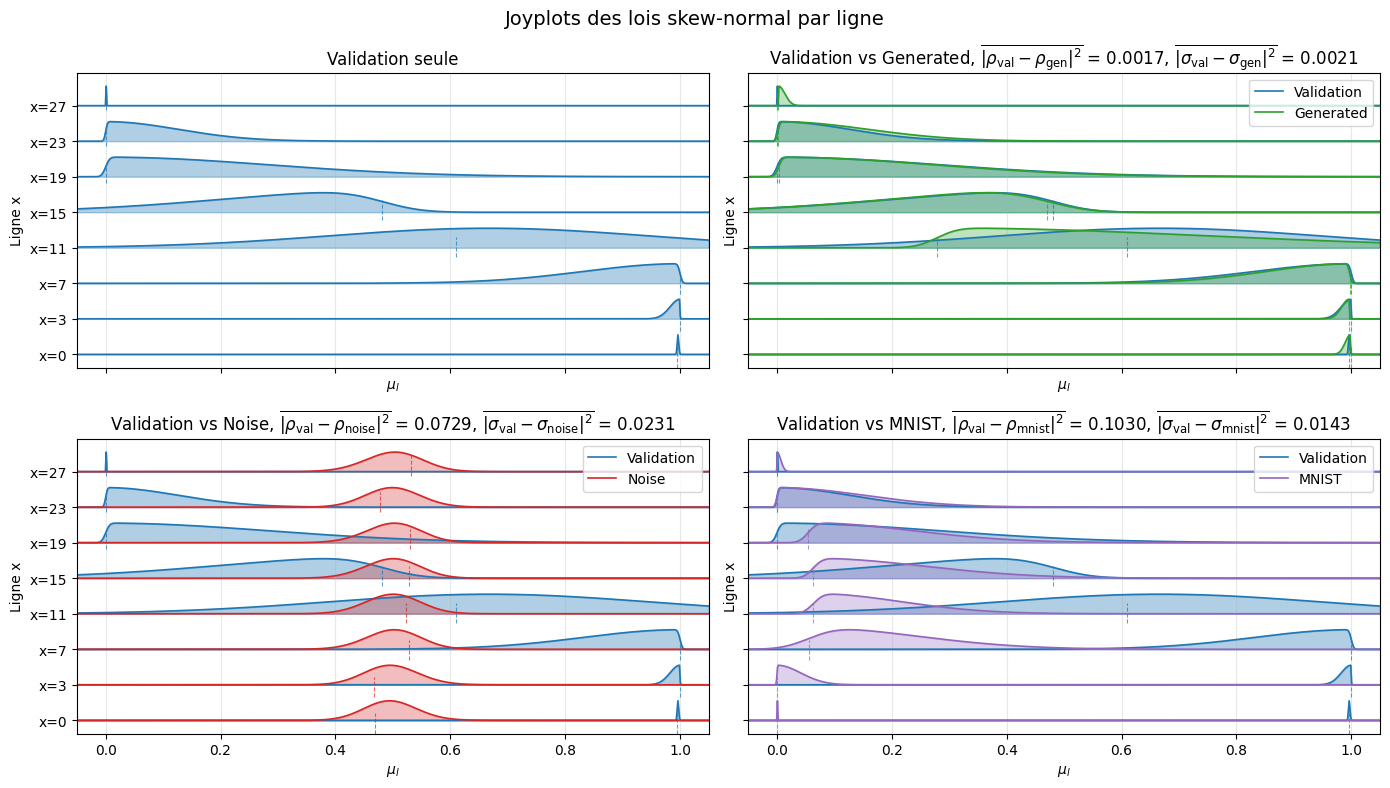

In [ ]:
title_2 = (
    "Validation vs Generated, "
    r"$\overline{|\rho_{\mathrm{val}} - \rho_{\mathrm{gen}}|^2}$"
    f" = {mu_l_dist_gen:.4f}, "
    r"$\overline{|\sigma_{\mathrm{val}} - \sigma_{\mathrm{gen}}|^2}$"
    f" = {sigma_l_dist_gen:.4f}"
)
title_3 = (
    "Validation vs Noise, "
    r"$\overline{|\rho_{\mathrm{val}} - \rho_{\mathrm{noise}}|^2}$"
    f" = {mu_l_dist_noise:.4f}, "
    r"$\overline{|\sigma_{\mathrm{val}} - \sigma_{\mathrm{noise}}|^2}$"
    f" = {sigma_l_dist_noise:.4f}"
)
title_4 = (
    "Validation vs MNIST, "
    r"$\overline{|\rho_{\mathrm{val}} - \rho_{\mathrm{mnist}}|^2}$"
    f" = {mu_l_dist_mnist:.4f}, "
    r"$\overline{|\sigma_{\mathrm{val}} - \sigma_{\mathrm{mnist}}|^2}$"
    f" = {sigma_l_dist_mnist:.4f}"
)

n_curves = 8
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True, sharey=True)

plot_skewnorm_joyplot(n_curves, alpha_l_val, loc_l_val, scale_l_val, ax=axes[0, 0], title="Validation seule")
plot_skewnorm_joyplot(n_curves, alpha_l_val, loc_l_val, scale_l_val, alpha_l_generated, loc_l_generated, scale_l_generated, ax=axes[0, 1], title=title_2, label2="Generated", color2="tab:green")
plot_skewnorm_joyplot(n_curves, alpha_l_val, loc_l_val, scale_l_val, alpha_l_noise, loc_l_noise, scale_l_noise, ax=axes[1, 0], title=title_3, label2="Noise", color2="tab:red")
plot_skewnorm_joyplot(n_curves, alpha_l_val, loc_l_val, scale_l_val, alpha_l_mnist, loc_l_mnist, scale_l_mnist, ax=axes[1, 1], title=title_4, label2="MNIST", color2="tab:purple")

fig.suptitle("Joyplots des lois skew-normal par ligne", fontsize=14)
fig.tight_layout()
plt.show()